In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from workalendar.asia import SouthKorea 

# statsmodel 확인
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool, cpu_count
from torch.utils.data import DataLoader, TensorDataset

# 오류 무시하는 방법
import warnings
warnings.filterwarnings("ignore")

In [85]:
df = pd.read_csv("/mnt/nvme/zongseung/SCI/기후데이터/demand_celcius.csv")
df = df.set_index("일시")
df = df.drop("Unnamed: 0", axis=1)
df.index = pd.to_datetime(df.index)

In [86]:
import datetime as dt
cal = SouthKorea()

def holiday_weekday(data):
    holiday_data = []

    for date in data.index:

        if date.weekday() in [5, 6] or cal.is_holiday(date) is True:  # 주말 (토요일=5, 일요일=6) / 공휴일까지 포함시켜서 확인한다.
            holiday_data.append(2) # 2번은 쉬는날
        else:  # 그 외 날짜 
            holiday_data.append(1) # 안쉬는날

    data["holiday_data"] = holiday_data    
    
    return data

def get_season_by_month(month):
    asd = []
    
    for i in month: 
        if 3 <= i <= 5: 
            asd.append(1) # 봄
        elif 6 <= i <= 8:
            asd.append(2) # 여름
        elif 9 <= i <= 11:
            asd.append(3)
        else:
            asd.append(4)
    return asd

In [87]:
df["month"] = df.index.month

df_holiday = holiday_weekday(df)
df_holiday["season"] = get_season_by_month(df_holiday["month"])

In [88]:
df_holiday.reset_index("일시", inplace=True)

In [89]:
from holidays import SouthKorea

cal = SouthKorea()

df_holiday["is_holiday"] = df_holiday["일시"].apply(lambda x: cal.__contains__(x))
df_holiday["holiday_name"] = df_holiday["일시"].apply(lambda x: cal.get(x) if x in cal else "")


In [90]:
len(df_holiday)

51144

In [91]:
df_holiday.drop("is_holiday", axis=1, inplace=True)

# 2020-2024까지 확인한다
df_holiday = df_holiday[df_holiday["일시"]>="2021-01-01"]

In [92]:
# 더미 변수 생성 알고리즘
def select_date(data):

        dummies = pd.get_dummies(data["holiday_data"]).astype("int")
        season_dummies = pd.get_dummies(data["season"]).astype("int")
        
        data = pd.concat([data, dummies], axis = 1)
        data.drop(["holiday_data", "season"], axis=1, inplace=True)

        data.rename(columns = {1:"weekday",
        2:"weekend"}, inplace=True)

        data = pd.concat([data, season_dummies], axis = 1)

        data.rename(columns = {1:"spring",
        2:"summer",
        3:"autoum",
        4:"winter"}, inplace=True)
        
        return data

df1 = select_date(df_holiday)

In [93]:
np.unique(df1["holiday_name"].values)

array(['', "Alternative holiday for Buddha's Birthday",
       "Alternative holiday for Children's Day",
       'Alternative holiday for Chuseok',
       'Alternative holiday for Hangul Day',
       'Alternative holiday for Korean New Year',
       'Alternative holiday for Liberation Day',
       'Alternative holiday for National Foundation Day',
       'Armed Forces Day', "Buddha's Birthday", "Children's Day",
       'Christmas Day', 'Chuseok', 'Hangul Day',
       'Independence Movement Day', 'Korean New Year', 'Liberation Day',
       'Local Election Day', 'Memorial Day',
       'National Assembly Election Day', 'National Foundation Day',
       "New Year's Day", 'Presidential Election Day',
       'Temporary Public Holiday', 'The day preceding Chuseok',
       'The day preceding Korean New Year', 'The second day of Chuseok',
       'The second day of Korean New Year'], dtype=object)

In [94]:
df1["is_holiday_dummies"] =  df1["holiday_name"].apply(lambda x: 0 if pd.isna(x) or x == '' else 1)

In [95]:
df1.drop("month", axis=1, inplace=True)
df1.set_index("일시", inplace=True)

In [96]:
# holiday_type은 따로 분리한다 
holiday_name = df1["holiday_name"]
df2=df1.drop("holiday_name", axis=1)

In [104]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from itertools import product

# --- 1. 데이터 분할 ---
total_len = len(df2)
train_end = int(total_len * 0.70)
val_end = int(total_len * 0.85)

train_df = df2.iloc[:train_end].copy()
val_df = df2.iloc[train_end:val_end].copy()
test_df = df2.iloc[val_end:].copy()

y_all = df2["power demand(MW)"].values

# --- 2. 시간 인덱스 ---
t_all = np.arange(len(y_all))

# --- 3. Fourier term 생성 함수 ---
def generate_fourier_terms(timesteps, period, K):
    terms = []
    for k in range(1, K + 1):
        terms.append(np.sin(2 * np.pi * k * timesteps / period))
        terms.append(np.cos(2 * np.pi * k * timesteps / period))
    return np.stack(terms, axis=1)

# --- 4. Grid Search for best (Kd, Kw, Ky) ---
daily_K_vals = [1, 2, 3]
weekly_K_vals = [1, 2, 3]
yearly_K_vals = [1, 2, 3]

best_mse = float('inf')
best_K_combo = None
best_model = None
best_X_all = None

for Kd, Kw, Ky in product(daily_K_vals, weekly_K_vals, yearly_K_vals):
    X_all = np.hstack([
        generate_fourier_terms(t_all, 24*7, Kd),       # 주간
        generate_fourier_terms(t_all, 24*31, Kw),      # 월간
        generate_fourier_terms(t_all, 8760 , Ky)      # 연간
    ])

    X_train = X_all[:train_end]
    X_val = X_all[train_end:val_end]
    y_train = y_all[:train_end]
    y_val = y_all[train_end:val_end]

    model = LinearRegression().fit(X_train, y_train)
    val_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, val_pred)

    if mse < best_mse:
        best_mse = mse
        best_K_combo = (Kd, Kw, Ky)
        best_model = model
        best_X_all = X_all

# --- 5. 전체 데이터 예측 및 잔차 계산 ---
seasonality_pred = best_model.predict(best_X_all)
residuals = y_all - seasonality_pred

# --- 6. 결과 정리 ---
df_result = df2.copy()
df_result = df_result.reset_index(drop=True)
df_result["t"] = t_all
df_result["Fourier_Seasonality"] = seasonality_pred
df_result["Fourier_Residual"] = residuals

# 결과 생성
Kd_best, Kw_best, Ky_best = best_K_combo
print(f"최적의 K 값 조합:")
print(f"  - 주간 주기 Kd = {Kd_best}")
print(f"  - 월간 주기 Kw = {Kw_best}")
print(f"  - 연간 주기 Ky = {Ky_best}")
print(f"  - 검증 MSE = {best_mse:.2f}")


최적의 K 값 조합:
  - 주간 주기 Kd = 3
  - 월간 주기 Kw = 1
  - 연간 주기 Ky = 3
  - 검증 MSE = 47295094.94


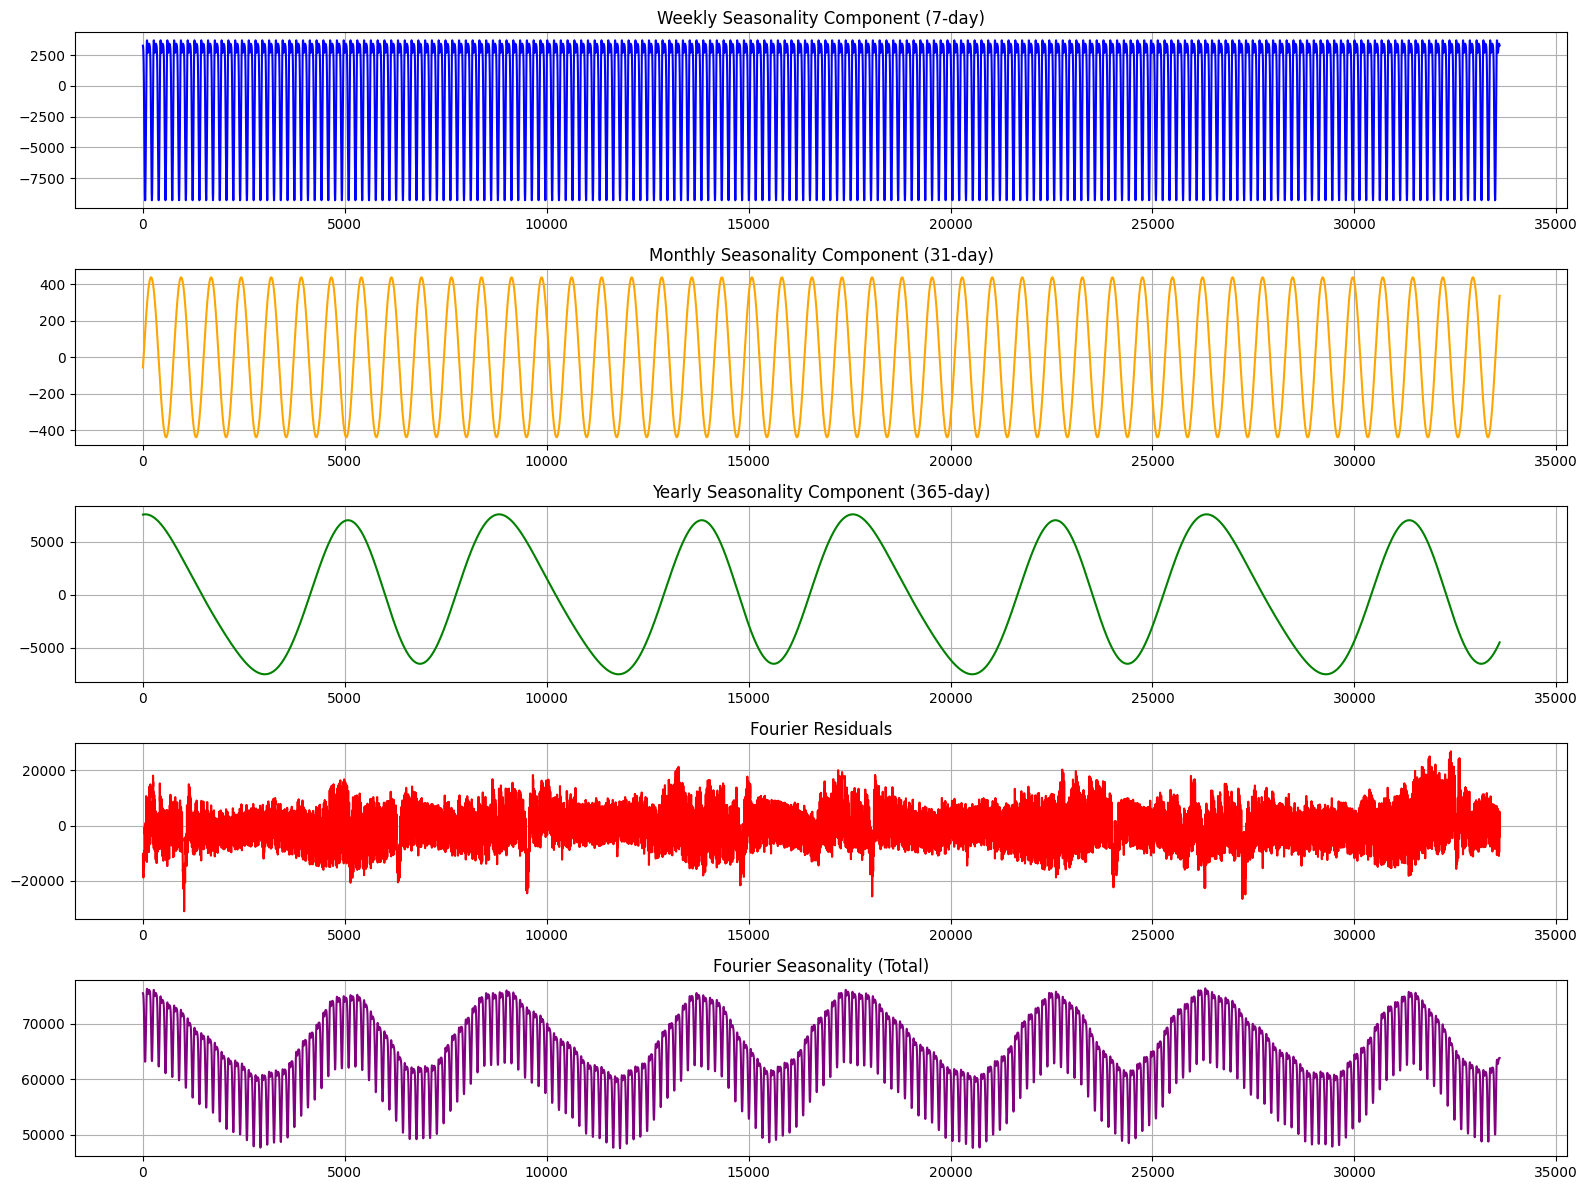

In [105]:
# --- 7. 시각화: 분해된 계절 성분 ---
Kd, Kw, Ky = best_K_combo

daily_terms = generate_fourier_terms(t_all, 7*24, Kd)
monthly_terms = generate_fourier_terms(t_all, 31*24, Kw)
yearly_terms = generate_fourier_terms(t_all, 365*24, Ky)

coef = best_model.coef_
daily_pred = daily_terms @ coef[:2*Kd]
monthly_pred = monthly_terms @ coef[2*Kd:2*Kd + 2*Kw]
yearly_pred = yearly_terms @ coef[2*Kd + 2*Kw:]

plt.figure(figsize=(16, 12))

plt.subplot(5, 1, 1)
plt.plot(df_result["t"], daily_pred, label="Weekly Seasonality", color='blue')
plt.title("Weekly Seasonality Component (7-day)")
plt.grid(True)

plt.subplot(5, 1, 2)
plt.plot(df_result["t"], monthly_pred, label="Monthly Seasonality", color='orange')
plt.title("Monthly Seasonality Component (31-day)")
plt.grid(True)

plt.subplot(5, 1, 3)
plt.plot(df_result["t"], yearly_pred, label="Yearly Seasonality", color='green')
plt.title("Yearly Seasonality Component (365-day)")
plt.grid(True)

plt.subplot(5, 1, 4)
plt.plot(df_result["t"], df_result["Fourier_Residual"], label="Residual", color='red')
plt.title("Fourier Residuals")
plt.grid(True)

plt.subplot(5, 1, 5)
plt.plot(df_result["t"], df_result["Fourier_Seasonality"], label="Fourier Seasonality", color='purple')
plt.title("Fourier Seasonality (Total)")
plt.grid(True)

plt.tight_layout()
plt.show()

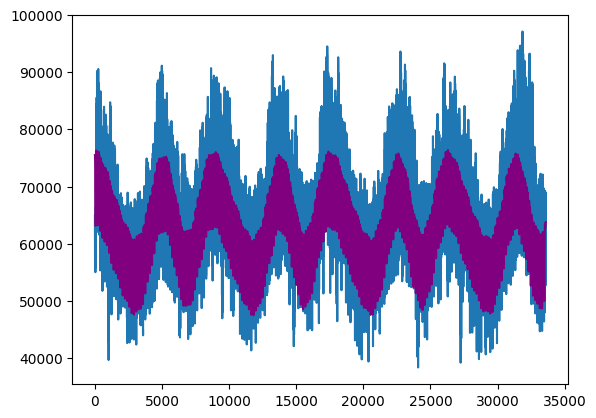

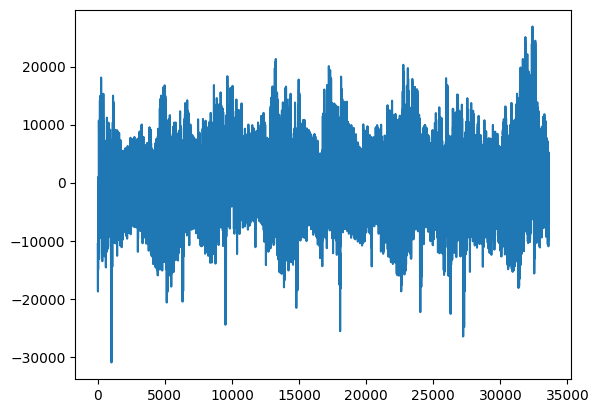

In [106]:
# 그래프 생성
plt.plot(df_result["t"], df_result["power demand(MW)"])
plt.plot(df_result["t"], df_result["Fourier_Seasonality"], label="Fourier Seasonality", color='purple')
plt.show()

# 잔차 생성
plt.plot(df_result["t"], df_result["Fourier_Residual"])

In [107]:
df_result.index = df1.index
df_result.drop("t", axis=1, inplace=True)

In [108]:
# 잘 생성은 된듯함 -> 이후 sarima를 위한 최적 파라미터를 확인한다.
total_len = len(df2)
train_end = int(total_len * 0.70)
val_end = int(total_len * 0.85)

train_df = df_result.iloc[:train_end].copy()
val_df = df_result.iloc[train_end:val_end].copy()
test_df = df_result.iloc[val_end:].copy()

In [19]:
from pmdarima import auto_arima

# 예: train_df의 수요열 사용
y_train = train_df["Fourier_Residual"]

model = auto_arima(
    y_train,
    seasonal=True,
    m=24,  # 주기 설정 (시간 단위 데이터에서 주간 계절성)
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None, D=None,  # 자동 차분 추정
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True  # 효율적인 탐색
)


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=317975.686, Time=0.83 sec


KeyboardInterrupt: 

In [109]:
# 잔차 진단.
model = SARIMAX(df_result.iloc[:val_end]["Fourier_Residual"],
                order = (1,1,2), seasonal_order=(1,0,1,24))

model_fit2 = model.fit(disp = True)
model_fit2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                     Fourier_Residual   No. Observations:                28560
Model:             SARIMAX(1, 1, 2)x(1, 0, [1], 24)   Log Likelihood             -240420.763
Date:                              Fri, 25 Apr 2025   AIC                         480853.526
Time:                                      11:40:20   BIC                         480903.085
Sample:                                  01-01-2021   HQIC                        480869.465
                                       - 04-04-2024                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4701      0.008     56.884      0.000       0.454       0.486
ma.L1          0.3301      0.007     45.803      0.000       0.316       0.344
ma.L2          0.1608      0.003     61.838      0.000       0.156       0.166
ar.S.L24       1.0000   1.74e-05   5.74e+04      0.000       1.000       1.000
ma.S.L24      -0.9234      0.006   -162.794      0.000      -0.934      -0.912
sigma2      2.558e+06   4.26e-10   6.01e+15      0.000    2.56e+06    2.56e+06
===================================================================================
Ljung-Box (L1) (Q):                  14.06   Jarque-Bera (JB):             11450.28
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.01   Skew:                            -0.38
Prob(H) (two-sided):                  0.80   Kurtosis:                         6.01
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.97e+30. Standard errors may be unstable.
"""

<Figure size 2000x1000 with 0 Axes>

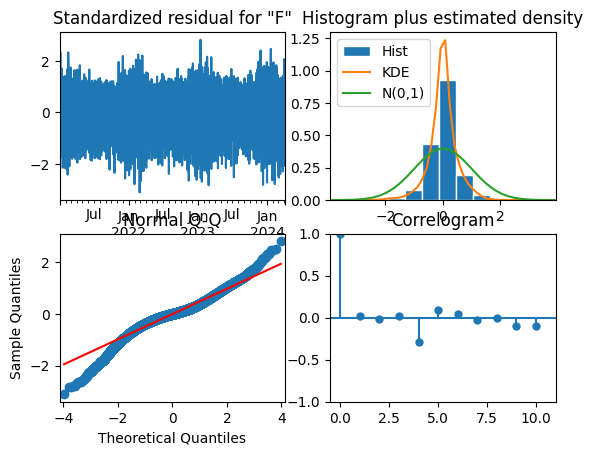

In [110]:
plt.figure(figsize=(20,10))
model_fit2.plot_diagnostics();
plt.show()

        lb_stat  lb_pvalue
24  6498.502828        0.0


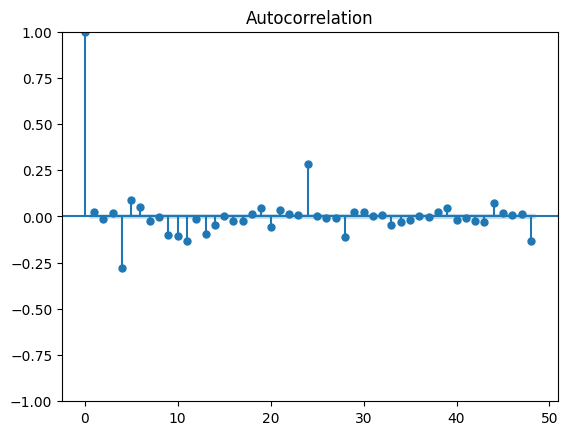

In [111]:
# 잔차 진단 확인 결과 백색잡음은 아닌듯 처럼 보임 -> 융 박스 테스트 점검
from statsmodels.graphics.tsaplots import plot_acf 
from statsmodels.stats.diagnostic import acorr_ljungbox

plot_acf(model_fit2.resid, lags=48); # 겉으로는 신뢰구간 안에 다 들어가 있는것처럼 보이나 융 박스 테스트 결과 잔차의 패턴이 있다는 것을 명확하게 보여줌

#
result = acorr_ljungbox(model_fit2.resid, lags=[24], return_df=True)
print(result) # 확인결과 백색잡음이 아님-> 어떤 유의한 패턴이 남아있음을 확인함.

In [112]:
df_train_residual = df_result[:train_end]
df_test_residual = df_result[train_end:]

In [113]:
import time
log_train_y = df_train_residual["Fourier_Residual"]
log_test_y = df_test_residual["Fourier_Residual"]
log_full_y = pd.concat([log_train_y, log_test_y], ignore_index=True)

# 2. 파라미터 설정
window_size = 24*7
n_periods = 1   # 하루 예측
start_index = 0
predictions = []
start_time = time.time()

# 3. 롤링 SARIMA 예측
for i in range(start_index, len(log_test_y), n_periods):
    try:
        step = min(n_periods, len(log_test_y) - i)
        
        window_start = len(log_train_y) + i - window_size
        window_end = len(log_train_y) + i

        if window_start < 0:
            print(f"⚠️ Step {i}: 학습 데이터 부족 (윈도우 범위 오류) → skip")
            continue

        # 4. 학습 데이터 슬라이싱
        train_endog = log_full_y.iloc[window_start:window_end].astype(float)

        # 5. 모델 재학습
        print(f"SARIMA 모델 업데이트: {i}/{len(log_test_y)}")
        sarima_model = SARIMAX(train_endog, order=(1,1,2), seasonal_order=(1,0,1,24), # (1,1,2), seasonal_order=(1,0,1,24)
                                      enforce_stationarity=False, enforce_invertibility=False)
        model_fit = sarima_model.fit(disp=False)

        # 6. 예측 수행
        fc = model_fit.forecast(steps=step)
        predictions.extend(fc)

        # 7. 진행상황 출력
        if (i // n_periods + 1) % 10 == 0:
            elapsed_time = time.time() - start_time
            print(f"⏱️ {i + step}/{len(log_test_y)} steps in {elapsed_time:.2f} seconds")
    
    except ValueError as e:
        print(f"⚠️ Step {i}에서 ValueError 발생: {e}")
        predictions.extend([np.nan] * step)
        continue

print("Rolling Window Validation 완료!")

# 8. 예측값 역변환 (log → 원래 단위로)
predictions1 = np.array(predictions)
# predictions_original = np.exp(predictions_log)

print("예측 완료! 최종 예측값 예시:")
print(predictions1)

SARIMA 모델 업데이트: 0/10080
SARIMA 모델 업데이트: 1/10080
SARIMA 모델 업데이트: 2/10080
SARIMA 모델 업데이트: 3/10080
SARIMA 모델 업데이트: 4/10080
SARIMA 모델 업데이트: 5/10080
SARIMA 모델 업데이트: 6/10080
SARIMA 모델 업데이트: 7/10080
SARIMA 모델 업데이트: 8/10080
SARIMA 모델 업데이트: 9/10080
⏱️ 10/10080 steps in 10.52 seconds
SARIMA 모델 업데이트: 10/10080
SARIMA 모델 업데이트: 11/10080
SARIMA 모델 업데이트: 12/10080
SARIMA 모델 업데이트: 13/10080
SARIMA 모델 업데이트: 14/10080
SARIMA 모델 업데이트: 15/10080
SARIMA 모델 업데이트: 16/10080
SARIMA 모델 업데이트: 17/10080
SARIMA 모델 업데이트: 18/10080
SARIMA 모델 업데이트: 19/10080
⏱️ 20/10080 steps in 19.78 seconds
SARIMA 모델 업데이트: 20/10080
SARIMA 모델 업데이트: 21/10080
SARIMA 모델 업데이트: 22/10080
SARIMA 모델 업데이트: 23/10080
SARIMA 모델 업데이트: 24/10080
SARIMA 모델 업데이트: 25/10080
SARIMA 모델 업데이트: 26/10080
SARIMA 모델 업데이트: 27/10080
SARIMA 모델 업데이트: 28/10080
SARIMA 모델 업데이트: 29/10080
⏱️ 30/10080 steps in 30.66 seconds
SARIMA 모델 업데이트: 30/10080
SARIMA 모델 업데이트: 31/10080
SARIMA 모델 업데이트: 32/10080
SARIMA 모델 업데이트: 33/10080
SARIMA 모델 업데이트: 34/10080
SARIMA 모델 업데이트: 35/10080
SARIM

In [122]:
pd.DataFrame(predictions1).to_csv("fourier_sarima.csv")

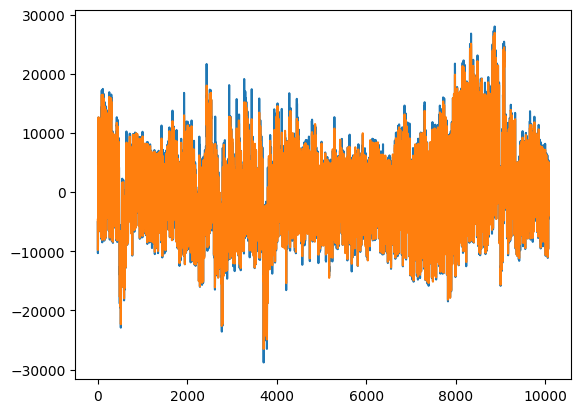

In [114]:
plt.plot(predictions1)
plt.plot(df_test_residual["Fourier_Residual"].values, label = "real")
# 
prediction_test_residual = predictions1 - df_test_residual["Fourier_Residual"].values

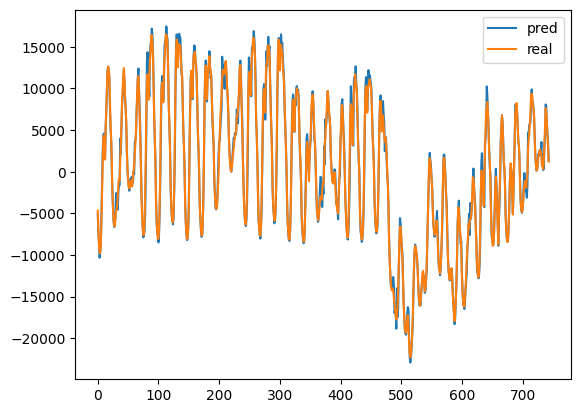

In [115]:
plt.plot(predictions1[:24*31], label = "pred")
plt.plot(df_test_residual["Fourier_Residual"][:24*31].values, label = "real")
plt.legend()

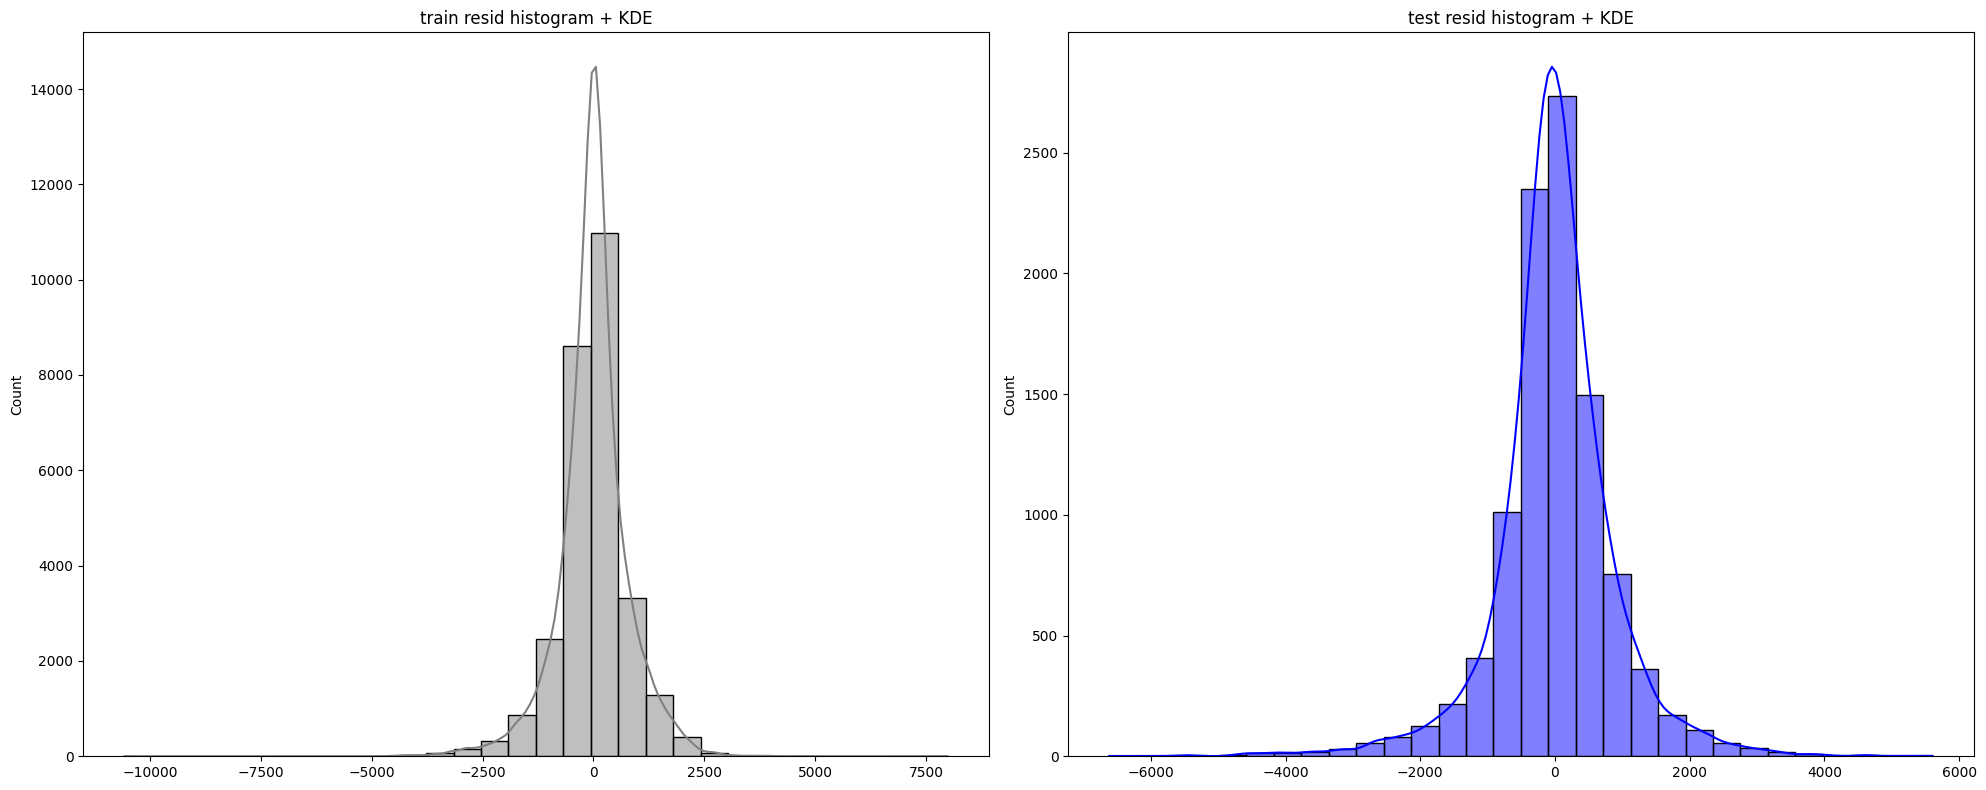

In [116]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(20, 8))

# 훈련 잔차 히스토그램 + KDE
sns.histplot(model_fit2.resid, bins=30, kde=True, ax=axs[0], color='grey', edgecolor='black')
axs[0].set_title("train resid histogram + KDE")

# 테스트 잔차 히스토그램 + KDE
sns.histplot(prediction_test_residual, bins=30, kde=True, ax=axs[1], color='blue', edgecolor='black')
axs[1].set_title("test resid histogram + KDE")

plt.tight_layout()
plt.show()

In [117]:
## 딥러닝 모델 적용간 전처리 주의 ## 
# 1. 스케일링
# 2. 적절한 윈도우 사이즈 생성하여 접근 아마 1달 접고 하루 예측하는 식으로 가지 않을까 싶음
# 3. 이후 최적 파라미터 찾아서 접근
# 4. 결과 더하기
from sklearn.preprocessing import MinMaxScaler
mnx = MinMaxScaler()
mny = MinMaxScaler()

# prediction_test_residual
train = df_train_residual.copy() 
train["sarima_residual"] = model_fit2.resid
train.drop(["Fourier_Seasonality", "Fourier_Residual", "power demand(MW)"], axis=1, inplace = True)

test = df_test_residual.copy()
test["sarima_pred_residual"] = prediction_test_residual
test.drop(["Fourier_Seasonality", "Fourier_Residual", "power demand(MW)"], axis=1, inplace = True)

# test에서 val-test 를 분리한다. 0.5 : 0.5 와 같이 처리됨
# 예: 절반씩 나누기
mid_index = len(test) // 2
val = test.iloc[:mid_index].reset_index(drop=True)
test_final = test.iloc[mid_index:].reset_index(drop=True)

# 이후 전처리 실시
train_x = train.copy()
train_y = train["sarima_residual"]

val_x = val.copy()
val_y = val["sarima_pred_residual"]

test_x = test_final.copy()
test_y = test_final["sarima_pred_residual"]

# validation, test 컬럼명 맞추기
val_x = val_x.rename(columns={"sarima_pred_residual": "sarima_residual"})
test_x = test_x.rename(columns={"sarima_pred_residual": "sarima_residual"})

# scaling 실시
scaled_train_x = mnx.fit_transform(train_x)
scaled_train_y = mny.fit_transform(train_y.values.reshape(-1,1))

scaled_val_x = mnx.transform(val_x)
scaled_val_y = mny.transform(val_y.values.reshape(-1,1))

scaled_test_x = mnx.transform(test_x)
scaled_test_y = mny.transform(test_y.values.reshape(-1,1))

In [118]:
def sliding_window(datax, datay, window_size):
    x = []
    y = []
    
    for i in range(len(datax) - window_size + 1):
        xx = datax[i:window_size + i]  # 윈도우 크기 만큼 입력 생성
        yy = datay[window_size + i - 1]  # 윈도우의 마지막 값을 출력으로 설정
        x.append(xx)
        y.append(yy)
    
    return np.array(x), np.array(y)

scaled_train_x1, scaled_train_y1 = sliding_window(scaled_train_x, scaled_train_y, window_size=24)
scaled_val_x1, scaled_val_y1 = sliding_window(scaled_val_x, scaled_val_y, window_size=24)
scaled_test_x1, scaled_test_y1 = sliding_window(scaled_test_x, scaled_test_y, window_size=24)

In [119]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import math
from torch.optim.lr_scheduler import StepLR

#############################################
# 1. CNN + LSTM 모델 정의
#############################################
class CNN_LSTM_Model(nn.Module):
    def __init__(self, lstm_layers, dense_layers, units, dense_units, lstm_dropout_rate, 
                 dense_dropout_rate, input_features, num_filters, kernel_size=7
                 ):
        super(CNN_LSTM_Model, self).__init__()

        # Conv1D 레이어 추가
        self.conv1 = nn.Conv1d(in_channels=input_features,
                               out_channels=num_filters,
                               kernel_size=kernel_size,
                               padding=kernel_size // 2)  # 길이 유지

        self.relu = nn.ReLU()

        # LSTM 레이어
        self.lstm = nn.LSTM(
                input_size=num_filters,
                hidden_size=units, 
                num_layers=lstm_layers, 
                batch_first=True
                )
        self.lstm_dropout = nn.Dropout(lstm_dropout_rate)

        # Dense 레이어
        self.dense_layers = nn.ModuleList(
            [nn.Sequential(
                nn.Linear(units if i == 0 else dense_units, dense_units),
                nn.ReLU(),
                nn.Dropout(dense_dropout_rate)
            ) for i in range(dense_layers)]
        )

        # 출력 레이어
        self.output_layer = nn.Linear(dense_units if dense_layers > 0 else units, 1)
        
    def forward(self, x):
        # Conv1D 적용 위해 (batch, channels, seq_len)
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        x = self.relu(x)
        x = x.permute(0, 2, 1)  # (batch, seq_len, filters)

        # LSTM
        x, _ = self.lstm(x)
        x = x[:, -1, :]
        x = self.lstm_dropout(x)

        # Dense
        for layer in self.dense_layers:
            x = layer(x)
        x = self.output_layer(x)
        return x

#############################################
# 2. DataLoader 생성
#############################################
def create_dataloader(X, Y, batch_size):
    dataset = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(Y, dtype=torch.float32))
    return DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=32, pin_memory=True)

#############################################
# 3. Fitness 함수 수정 (num_filters 포함)
#############################################
def fitness_function(params, X_train, Y_train, X_val, Y_val, device):
    # [num_filters, lstm_layers, dense_layers, units, dense_units, learning_rate, lstm_dropout_rate, dense_dropout_rate, batch_size, kernel_size]
    (num_filters, lstm_layers, dense_layers, units, dense_units, learning_rate, 
     lstm_dropout_rate, dense_dropout_rate, batch_size, kernel_size) = (
        int(params[0]), int(params[1]), int(params[2]), int(params[3]), int(params[4]),
        params[5], params[6], params[7], int(params[8]), int(params[9])
    )

    input_features = X_train.shape[2]
    model = CNN_LSTM_Model(
        lstm_layers=lstm_layers,
        dense_layers=dense_layers,
        units=units,
        dense_units=dense_units,
        lstm_dropout_rate=lstm_dropout_rate,
        dense_dropout_rate=dense_dropout_rate,
        input_features=input_features,
        num_filters=num_filters,
        kernel_size=kernel_size  # 추가
    ).to(device)

    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    train_loader = create_dataloader(X_train, Y_train, batch_size)
    
    model.train()
    for epoch in range(30):  # 빠른 평가
        for batch_X, batch_Y in train_loader:
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_Y)
            loss.backward()
            optimizer.step()
    
    model.eval()
    with torch.no_grad():
        X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
        Y_val_tensor = torch.tensor(Y_val, dtype=torch.float32).to(device)
        val_predictions = model(X_val_tensor)
        val_loss = criterion(val_predictions, Y_val_tensor).item()
    return val_loss

#############################################
# 4. 보조 함수: Bounds, swapfun
#############################################
import math
def Bounds(s, Lb, Ub):
    return np.minimum(np.maximum(s, Lb), Ub)  # ✅ NumPy 벡터 연산 활용


def swapfun(ss):
    o = np.zeros((1, len(ss)))
    for i in range(len(ss)):
        o[0, i] = ss[i]
    return o

#############################################
# 5. 수정된 DBO 함수 (벡터 하한/상한 사용)
#############################################

def DBO(pop, M, lb_vector, ub_vector, dim, fun):
    """
    :param pop: 인구수
    :param M: 반복 횟수 (세대 수)
    :param lb_vector: 각 차원의 하한을 담은 배열 (shape=(dim,))
    :param ub_vector: 각 차원의 상한을 담은 배열 (shape=(dim,))
    :param dim: 최적화할 차원 수 (여기서는 8)
    :param fun: fitness 함수 (최소화 대상)
    :return: 최적 fitness, 최적 파라미터, 수렴 곡선
    """
    lb = lb_vector.reshape(1, dim)
    ub = ub_vector.reshape(1, dim)
    
    P_percent = 0.2
    pNum = round(pop * P_percent)
    X = np.zeros((pop, dim))
    fit = np.zeros((pop, 1))
    
    for i in range(pop):
        X[i, :] = lb + (ub - lb) * np.random.rand(1, dim)
        fit[i, 0] = fun(X[i, :])
    
    pFit = fit.copy()
    pX = X.copy()
    XX = pX.copy()
    fMin = np.min(fit[:, 0])
    bestI = np.argmin(fit[:, 0])
    bestX = X[bestI, :].copy()
    Convergence_curve = np.zeros((1, M))
    
    for t in range(M):
        fmax = np.max(pFit[:, 0])
        B = np.argmax(pFit[:, 0])
        worse = X[B, :].copy()  # 현재 최악 해
        
        r2 = np.random.rand(1)
        for i in range(pNum):
            if r2 < 0.9:
                r1 = np.random.rand(1)
                a = np.random.rand(1)
                a = 1 if a > 0.1 else -1
                X[i, :] = pX[i, :] + 0.3 * np.abs(pX[i, :] - worse) + a * 0.1 * (XX[i, :])
            else:
                aaa = np.random.randint(0, 180, size=1)
                if aaa in [0, 90, 180]:
                    X[i, :] = pX[i, :]
                else:
                    theta = aaa * math.pi / 180
                    X[i, :] = pX[i, :] + math.tan(theta) * np.abs(pX[i, :] - XX[i, :])
            X[i, :] = Bounds(X[i, :], lb, ub)
            fit[i, 0] = fun(X[i, :])
        
        bestII = np.argmin(fit[:, 0])
        bestXX = X[bestII, :].copy()
        
        R = 1 - t / M
        Xnew1 = bestXX * (1 - R)
        Xnew2 = bestXX * (1 + R)
        Xnew1 = Bounds(Xnew1, lb, ub)
        Xnew2 = Bounds(Xnew2, lb, ub)
        Xnew11 = bestX * (1 - R)
        Xnew22 = bestX * (1 + R)
        Xnew11 = Bounds(Xnew11, lb, ub)
        Xnew22 = Bounds(Xnew22, lb, ub)
        
        for i in range(pNum+1, min(12, pop)):
            rand1 = np.random.rand(1, dim)
            rand2 = np.random.rand(1, dim)
            X[i, :] = bestXX + rand1 * (pX[i, :] - Xnew1) + rand2 * (pX[i, :] - Xnew2)
            X[i, :] = Bounds(X[i, :], Xnew1, Xnew2)
            fit[i, 0] = fun(X[i, :])
        
        for i in range(13, min(19, pop)):
            X[i, :] = pX[i, :] + (np.random.randn(1) * (pX[i, :] - Xnew11) +
                                  np.random.rand(1, dim) * (pX[i, :] - Xnew22))
            X[i, :] = Bounds(X[i, :], lb, ub)
            fit[i, 0] = fun(X[i, :])
        
        for j in range(20, pop):
            X[j, :] = bestX + np.random.randn(1, dim) * (np.abs(pX[j, :] - bestXX) +
                                                         np.abs(pX[j, :] - bestX)) / 2
            X[j, :] = Bounds(X[j, :], lb, ub)
            fit[j, 0] = fun(X[j, :])
        
        # 업데이트: 개선된 해 저장
        XX = pX.copy()
        for i in range(pop):
            if fit[i, 0] < pFit[i, 0]:
                pFit[i, 0] = fit[i, 0]
                pX[i, :] = X[i, :].copy()
            if pFit[i, 0] < fMin:
                fMin = pFit[i, 0]
                bestX = pX[i, :].copy()

                # 최적 파라미터 출력
                print(f"New Best Fitness: {fMin:.6f}, Best Parameters: {bestX}")

        Convergence_curve[0, t] = fMin
        print(f"Iteration {t+1}, Best Fitness: {fMin:.6f}")
        
    return fMin, bestX, Convergence_curve

#############################################
# 6. 최종 학습 함수 수정 (CNN 포함)
#############################################
def train_model(X_train, Y_train, X_val, Y_val, X_test, Y_test, best_params, device):
    # unpack
    (num_filters, lstm_layers, dense_layers, units, dense_units, learning_rate, 
     lstm_dropout_rate, dense_dropout_rate, batch_size, kernel_size) = (
        int(best_params[0]), int(best_params[1]), int(best_params[2]), int(best_params[3]),
        int(best_params[4]), best_params[5], best_params[6], best_params[7], int(best_params[8]), int(best_params[9])
    )
    
    input_features = X_train.shape[2]
    model = CNN_LSTM_Model(
        lstm_layers=lstm_layers,
        dense_layers=dense_layers,
        units=units,
        dense_units=dense_units,
        lstm_dropout_rate=lstm_dropout_rate,
        dense_dropout_rate=dense_dropout_rate,
        input_features=input_features,
        num_filters=num_filters,
        kernel_size=kernel_size  # 추가
    ).to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

    # ------------------------------
    # (추가) Learning Rate Scheduler
    # ------------------------------
    # 예) ReduceLROnPlateau를 사용: 검증 손실이 개선되지 않으면 LR을 줄임
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,        # 학습률 감소 비율 (예: 0.5면 절반으로 감소)
        patience=5,        # 5 epoch 연속 개선 없으면 LR 감소
        cooldown=2,        # LR 감소 후 2 epoch 동안은 관찰만 수행
        min_lr=1e-6,       # 학습률 최솟값
        verbose=True       # LR 변동 시 메시지 출력
    )

    # EarlyStopping
    patience = 10
    best_val_loss = float('inf')
    patience_counter = 0

    train_loader = create_dataloader(X_train, Y_train, batch_size)
    val_loader = create_dataloader(X_val, Y_val, batch_size)
    test_loader = create_dataloader(X_test, Y_test, batch_size)
    
    train_losses = []
    val_losses = []
    epochs = 150

    for epoch in range(epochs):
        # --------------------
        # 1) Training phase
        # --------------------
        model.train()
        epoch_train_loss = 0.0
        for batch_X, batch_Y in train_loader:
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
            optimizer.zero_grad()
            preds = model(batch_X)
            loss = criterion(preds, batch_Y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
        train_losses.append(epoch_train_loss / len(train_loader))
        
        # --------------------
        # 2) Validation phase
        # --------------------
        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_Y in val_loader:
                batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
                preds = model(batch_X)
                loss = criterion(preds, batch_Y)
                epoch_val_loss += loss.item()
        val_loss_avg = epoch_val_loss / len(val_loader)
        val_losses.append(val_loss_avg)

        # -----------------------------
        # (추가) Scheduler step
        # -----------------------------
        # ReduceLROnPlateau는 val_loss(검증 손실)를 넣어줘야 함.
        scheduler.step(val_loss_avg)

        # -----------------------------
        # 3) Early Stopping Check
        # -----------------------------
        if val_loss_avg < best_val_loss:
             best_val_loss = val_loss_avg
             patience_counter = 0
        else:
             patience_counter += 1
             if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")
    
    print("Final model training complete.")
    
    # --------------------
    # 4) Test evaluation
    # --------------------
    model.eval()
    test_loss = 0.0
    test_preds = []
    with torch.no_grad():
        for batch_X, batch_Y in test_loader:
            batch_X, batch_Y = batch_X.to(device), batch_Y.to(device)
            preds = model(batch_X)
            loss = criterion(preds, batch_Y)
            test_loss += loss.item()
            test_preds.append(preds.cpu().numpy())
            
    test_loss /= len(test_loader)
    test_preds = np.concatenate(test_preds, axis=0)
    
    return model, train_losses, val_losses, test_loss, test_preds

In [120]:
if __name__ == '__main__':
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    torch.backends.cudnn.benchmark = True 
    torch.backends.cudnn.enabled = True
    
    # 하이퍼파라미터 범위 설정 (num_filters 포함 9개)
    # [num_filters, lstm_layers, dense_layers, units, dense_units, learning_rate, lstm_dropout_rate, dense_dropout_rate, batch_size]
    lb_params = np.array([16, 1, 1, 32, 32, 1e-4, 0.1, 0.1, 16, 3])   # kernel_size 하한 = 3
    ub_params = np.array([128, 3, 3, 256, 256, 1e-2, 0.5, 0.5, 128, 11]) # kernel_size 상한 = 11

    pop = 20  # 개체 수 20
    M = 5     # 반복 횟수 5

    # DBO 실행
    best_loss, best_params, convergence = DBO(
        pop, M, lb_params, ub_params, 10,
        lambda params: fitness_function(params, scaled_train_x1, scaled_train_y1, scaled_val_x1, scaled_val_y1, device)
    )

    print("최적 검증 손실:", best_loss)
    print("최적 하이퍼파라미터:", best_params)

    # 최적 모델 학습 및 평가
    final_model, train_losses, val_losses, test_loss, test_preds = train_model(
        scaled_train_x1, scaled_train_y1, scaled_val_x1, scaled_val_y1, scaled_test_x1, scaled_test_y1, best_params, device
    )

    print("최종 모델 학습 후 Validation Loss:", val_losses[-1])
    print("테스트 데이터 손실:", test_loss)

KeyboardInterrupt: 

In [121]:
if __name__ == '__main__':
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    torch.backends.cudnn.benchmark = True 
    torch.backends.cudnn.enabled = True
    
    # best_params
    best_params = [4.54177140e+01, 2.34194776e+00, 2.01777740e+00, 1.07564303e+02,
       2.01227403e+02, 2.59563017e-03, 4.28271748e-01, 4.39936619e-01,
       4.40834041e+01, 6.24639814e+00]
    
    # 최적 모델 학습 및 평가
    final_model, train_losses, val_losses, test_loss, test_preds = train_model(
        scaled_train_x1, scaled_train_y1, scaled_val_x1, scaled_val_y1, scaled_test_x1, scaled_test_y1, best_params, device
    )

    print("최종 모델 학습 후 Validation Loss:", val_losses[-1])
    print("테스트 데이터 손실:", test_loss)

Epoch [10/150], Train Loss: 0.0004, Val Loss: 0.0031
Epoch [20/150], Train Loss: 0.0003, Val Loss: 0.0004
Epoch [30/150], Train Loss: 0.0002, Val Loss: 0.0002
Epoch [40/150], Train Loss: 0.0001, Val Loss: 0.0001
Epoch [50/150], Train Loss: 0.0001, Val Loss: 0.0002
Early stopping at epoch 58
Final model training complete.
최종 모델 학습 후 Validation Loss: 0.00018049403680260698
테스트 데이터 손실: 0.00020137505895906108


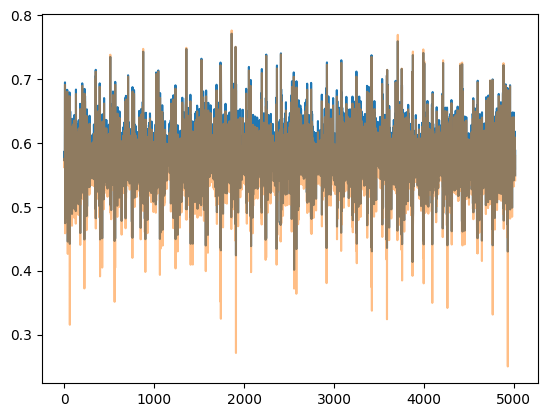

In [123]:
plt.plot(test_preds)
plt.plot(scaled_test_y1, alpha=0.5)

In [124]:
inverse_preds = mny.inverse_transform(test_preds)
inverse_preds

array([[  91.927666],
       [ 315.4015  ],
       [  50.417152],
       ...,
       [-210.75308 ],
       [ 366.31235 ],
       [-376.30176 ]], dtype=float32)

In [125]:
sad = inverse_preds.flatten()+ predictions1[-len(test_preds):] + df_test_residual["Fourier_Seasonality"][-len(test_preds):].values

0.9783449610424603
0.018047332714710276
1601.4175881065278


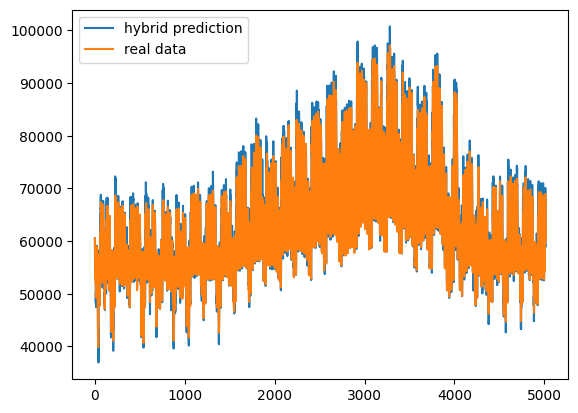

In [126]:
plt.plot(sad, label = "hybrid prediction")
plt.plot(df_test_residual["power demand(MW)"][-len(test_preds):].values, label = "real data")
plt.legend()

pred = sad.copy()
real = df_test_residual["power demand(MW)"][-len(test_preds):].values.copy()

from sklearn.metrics import r2_score, mean_absolute_percentage_error, root_mean_squared_error
r2 = r2_score(real, pred)
mape = mean_absolute_percentage_error(real, pred)
rmse = root_mean_squared_error(real, pred)

print(r2)
print(mape)
print(rmse)